# 05. Análisis de resultados y sesgos

Aquí miro cuándo el modelo funciona y cuándo no. Calibración por resultado, hit rate por rango de cuota, deriva temporal, estacionalidad, sesgos por tipo de apuesta y un análisis específico de la peor temporada (2019).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Cargar resultados del backtest
bets_path    = '../results/backtest_master_bets.csv'
seasons_path = '../results/backtest_master_seasons.csv'

df_bets    = pd.read_csv(bets_path)
df_seasons = pd.read_csv(seasons_path)
df_bets['Date'] = pd.to_datetime(df_bets['Date'])

print(f'Total apuestas: {len(df_bets)}')
print(f'Temporadas:     {sorted(df_bets["Season"].unique())}')
print(df_bets.head())


Total apuestas: 344
Temporadas:     [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
   Season       Date    HomeTeam    AwayTeam  Bet_Type  Odds   P_Model  \
0    2012 2012-08-20   Vallecano     Granada         1   2.2  0.489034   
1    2012 2012-09-01   La Coruna      Getafe         1   2.2  0.479817   
2    2012 2012-09-02  Ath Bilbao  Valladolid         1   2.0  0.539670   
3    2012 2012-09-16     Espanol  Ath Bilbao         1   2.2  0.549154   
4    2012 2012-09-16     Osasuna    Mallorca         1   2.2  0.502666   

         EV    Won  Flat_Stake  Flat_Profit  Kelly_Stake  Kelly_Profit  \
0  0.075875   True        10.0         12.0    15.807242     18.968691   
1  0.055598  False        10.0        -10.0    11.802685    -11.802685   
2  0.079339   True        10.0         10.0    19.976924     19.976924   
3  0.208138  F

## 1. Calibración: ¿son fiables las probabilidades?

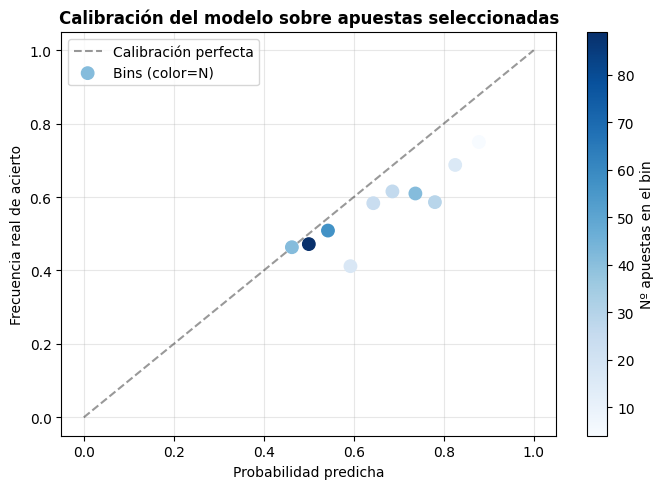

         P_bin  P_media  Hit_real  N
(0.431, 0.479] 0.462500  0.463415 41
(0.479, 0.525] 0.500165  0.471910 89
(0.525, 0.572] 0.542660  0.508772 57
(0.572, 0.618] 0.592637  0.411765 17
(0.618, 0.665] 0.643376  0.583333 24
(0.665, 0.711] 0.685891  0.615385 26
(0.711, 0.757] 0.736931  0.609756 41
(0.757, 0.804] 0.780362  0.586207 29
 (0.804, 0.85] 0.825439  0.687500 16
 (0.85, 0.897] 0.878034  0.750000  4


In [2]:
# Dividir apuestas en deciles de probabilidad y calcular hit rate real
fig, ax = plt.subplots(figsize=(7, 5))

n_bins = 10
bins   = np.linspace(df_bets['P_Model'].min(), df_bets['P_Model'].max(), n_bins+1)
df_bets['P_bin'] = pd.cut(df_bets['P_Model'], bins=bins, include_lowest=True)
calib = df_bets.groupby('P_bin', observed=True).agg(
    P_media=('P_Model','mean'),
    Hit_real=('Won','mean'),
    N=('Won','count')
).reset_index()

ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Calibración perfecta')
sc = ax.scatter(calib['P_media'], calib['Hit_real'], c=calib['N'],
                cmap='Blues', s=80, zorder=5, label='Bins (color=N)')
plt.colorbar(sc, ax=ax, label='Nº apuestas en el bin')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Frecuencia real de acierto')
ax.set_title('Calibración del modelo sobre apuestas seleccionadas', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/analisis_calibracion.png', dpi=120, bbox_inches='tight')
plt.show()
print(calib[['P_bin','P_media','Hit_real','N']].to_string(index=False))


## 2. Hit rate por rango de cuota

¿Hay edge en todos los rangos o se concentra en alguno?

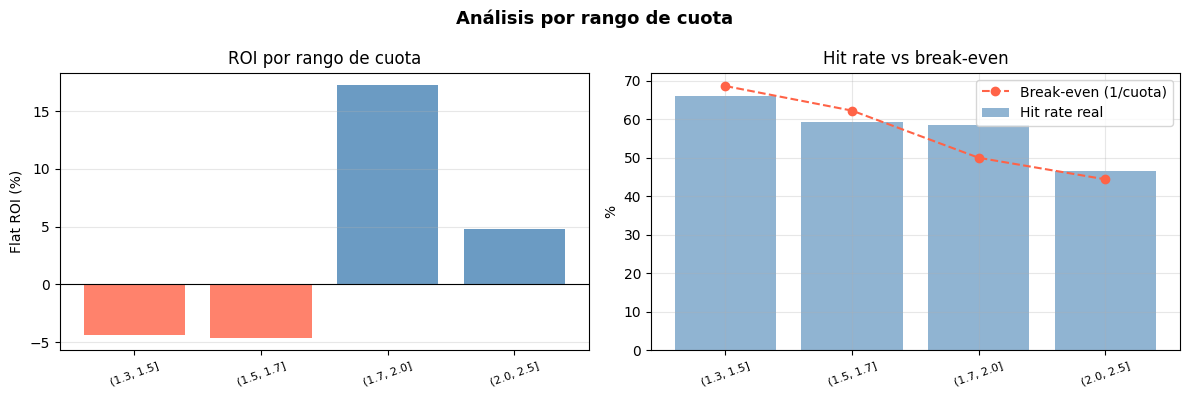

  Odds_bin   N      Hit  Flat_ROI       BE
(1.3, 1.5]  56 0.660714 -0.043750 0.686275
(1.5, 1.7]  64 0.593750 -0.046250 0.622447
(1.7, 2.0]  29 0.586207  0.172414 0.500000
(2.0, 2.5] 195 0.466667  0.047744 0.444060


In [3]:
odds_bins = [1.0, 1.30, 1.50, 1.70, 2.00, 2.50, 3.00, 4.00, 10.0]
df_bets['Odds_bin'] = pd.cut(df_bets['Odds'], bins=odds_bins, include_lowest=True)

by_odds = df_bets.groupby('Odds_bin', observed=True).agg(
    N=('Won','count'),
    Hit=('Won','mean'),
    Flat_ROI=('Flat_Profit', lambda x: x.sum() / (len(x) * 10.0)),
    Odds_media=('Odds','mean')
).reset_index()

# Break-even: 1 / odds_media
by_odds['BE'] = 1.0 / by_odds['Odds_media']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['steelblue' if r > 0 else 'tomato' for r in by_odds['Flat_ROI']]
axes[0].bar(range(len(by_odds)), by_odds['Flat_ROI']*100, color=colors, alpha=0.8)
axes[0].set_xticks(range(len(by_odds)))
axes[0].set_xticklabels([str(b) for b in by_odds['Odds_bin']], rotation=20, fontsize=8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Flat ROI (%)'); axes[0].set_title('ROI por rango de cuota'); axes[0].grid(axis='y',alpha=0.3)

axes[1].bar(range(len(by_odds)), by_odds['Hit']*100, color='steelblue', alpha=0.6, label='Hit rate real')
axes[1].plot(range(len(by_odds)), by_odds['BE']*100, 'o--', color='tomato', label='Break-even (1/cuota)')
axes[1].set_xticks(range(len(by_odds)))
axes[1].set_xticklabels([str(b) for b in by_odds['Odds_bin']], rotation=20, fontsize=8)
axes[1].set_ylabel('%'); axes[1].set_title('Hit rate vs break-even'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Análisis por rango de cuota', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/analisis_por_odds.png', dpi=120, bbox_inches='tight')
plt.show()
print(by_odds[['Odds_bin','N','Hit','Flat_ROI','BE']].to_string(index=False))


## 3. Deriva temporal: ¿pierde el modelo potencia con los años?

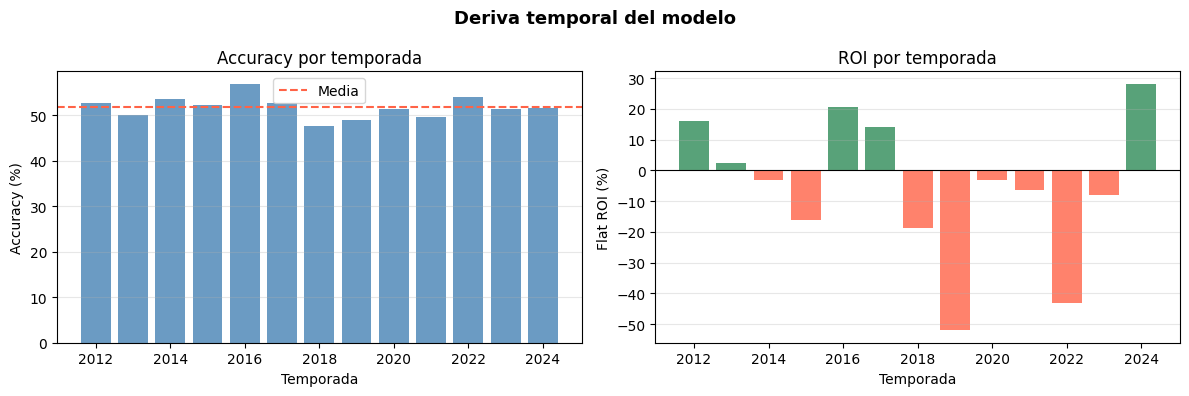

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

seasons = df_seasons['Season'].astype(int)
axes[0].bar(seasons, df_seasons['Accuracy']*100, color='steelblue', alpha=0.8)
axes[0].axhline(df_seasons['Accuracy'].mean()*100, color='tomato', linestyle='--', label='Media')
axes[0].set_xlabel('Temporada'); axes[0].set_ylabel('Accuracy (%)'); axes[0].set_title('Accuracy por temporada')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

colors = ['seagreen' if r > 0 else 'tomato' for r in df_seasons['Flat_ROI']]
axes[1].bar(seasons, df_seasons['Flat_ROI']*100, color=colors, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Temporada'); axes[1].set_ylabel('Flat ROI (%)'); axes[1].set_title('ROI por temporada')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Deriva temporal del modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/analisis_deriva_temporal.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Estacionalidad: ¿hay meses mejores?

A principio de temporada (sep-oct) los equipos están menos asentados y hay más incertidumbre. Al final (abr-may) la información está más cocida y debería ayudar al modelo. Lo compruebo.

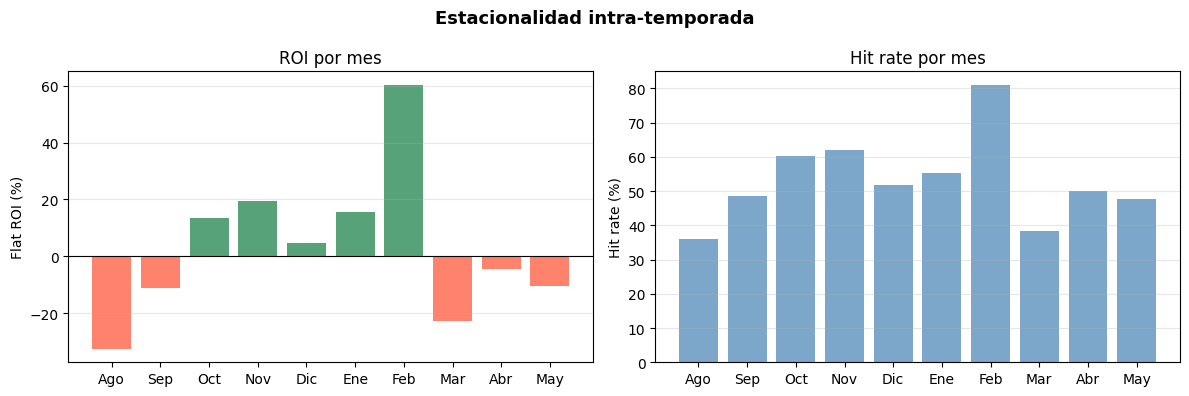

In [5]:
df_bets['Month'] = df_bets['Date'].dt.month
monthly = df_bets.groupby('Month').agg(
    N=('Won','count'),
    Hit=('Won','mean'),
    ROI=('Flat_Profit', lambda x: x.sum() / (len(x) * 10.0))
).reset_index()

month_names = {8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic',
               1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',7:'Jul'}
monthly['Month_name'] = monthly['Month'].map(month_names)
# Ordenar por calendario de temporada (ago->jul)
season_order = [8,9,10,11,12,1,2,3,4,5,6,7]
monthly['order'] = monthly['Month'].map({m:i for i,m in enumerate(season_order)})
monthly = monthly.sort_values('order')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['seagreen' if r > 0 else 'tomato' for r in monthly['ROI']]
axes[0].bar(range(len(monthly)), monthly['ROI']*100, color=colors, alpha=0.8)
axes[0].set_xticks(range(len(monthly))); axes[0].set_xticklabels(monthly['Month_name'])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Flat ROI (%)'); axes[0].set_title('ROI por mes'); axes[0].grid(axis='y',alpha=0.3)

axes[1].bar(range(len(monthly)), monthly['Hit']*100, color='steelblue', alpha=0.7)
axes[1].set_xticks(range(len(monthly))); axes[1].set_xticklabels(monthly['Month_name'])
axes[1].set_ylabel('Hit rate (%)'); axes[1].set_title('Hit rate por mes'); axes[1].grid(axis='y',alpha=0.3)

plt.suptitle('Estacionalidad intra-temporada', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/analisis_estacionalidad.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Sesgo por tipo de apuesta: locales o visitantes

Breakdown por tipo de apuesta:
 Bet_Type   N      Hit  Flat_ROI  Avg_Odds   Avg_EV
        1 344 0.531977  0.025872   1.98125 0.155254


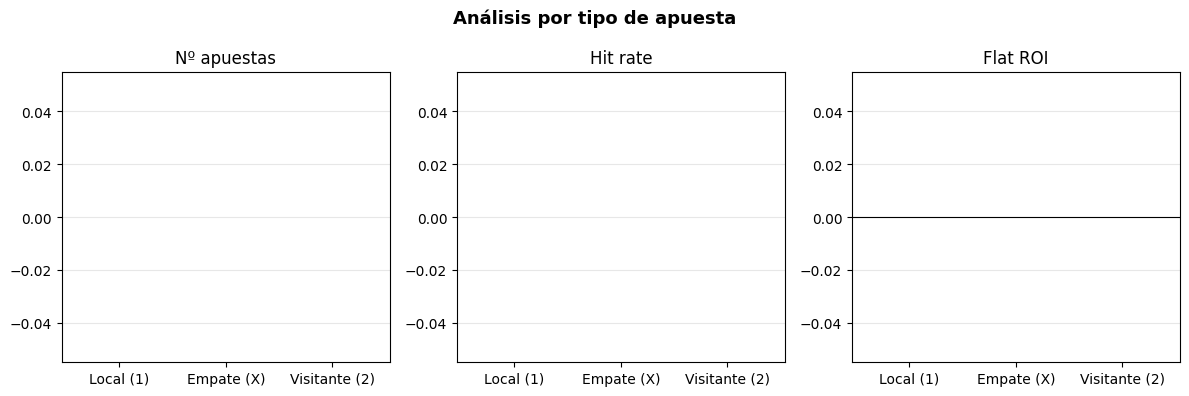

In [6]:
by_type = df_bets.groupby('Bet_Type').agg(
    N=('Won','count'),
    Hit=('Won','mean'),
    Flat_ROI=('Flat_Profit', lambda x: x.sum() / (len(x) * 10.0)),
    Avg_Odds=('Odds','mean'),
    Avg_EV=('EV','mean')
).reset_index()

print('Breakdown por tipo de apuesta:')
print(by_type.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = {'1': 'steelblue', 'X': 'goldenrod', '2': 'tomato'}
for ax, col, title in zip(axes,
    ['N', 'Hit', 'Flat_ROI'],
    ['Nº apuestas', 'Hit rate', 'Flat ROI']):
    vals  = [by_type.loc[by_type['Bet_Type']==bt, col].values[0]
             if bt in by_type['Bet_Type'].values else 0 for bt in ['1','X','2']]
    if col in ['Hit','Flat_ROI']:
        vals = [v*100 for v in vals]
    ax.bar(['Local (1)','Empate (X)','Visitante (2)'], vals,
           color=[colors['1'], colors['X'], colors['2']], alpha=0.8)
    if col == 'Flat_ROI':
        ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Análisis por tipo de apuesta', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/analisis_por_tipo.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Análisis de las peores temporadas

In [7]:
# Identificar temporadas con ROI negativo y analizar que paso
bad_seasons = df_seasons[df_seasons['Flat_ROI'] < 0]['Season'].tolist()
print(f'Temporadas negativas: {bad_seasons}')

for s in bad_seasons:
    sub = df_bets[df_bets['Season'] == s]
    if sub.empty: continue
    roi = sub['Flat_Profit'].sum() / (len(sub) * 10.0)
    print(f'\n  --- Temporada {int(s)} ---')
    print(f'  Apuestas: {len(sub)} | Hit: {sub["Won"].mean():.1%} | ROI: {roi:+.2%}')
    print(f'  Por tipo:')
    for bt in sub['Bet_Type'].unique():
        ss = sub[sub['Bet_Type']==bt]
        r  = ss['Flat_Profit'].sum() / (len(ss)*10.0)
        print(f'    {bt}: {len(ss)} bets, hit={ss["Won"].mean():.1%}, ROI={r:+.2%}')
    # Maxima racha perdedora
    streak = mx = 0
    for p in sub['Flat_Profit']:
        streak = streak+1 if p < 0 else 0
        mx = max(mx, streak)
    print(f'  Max racha perdedora: {mx} apuestas')


Temporadas negativas: [2014, 2015, 2018, 2019, 2020, 2021, 2022, 2023]

  --- Temporada 2014 ---
  Apuestas: 15 | Hit: 53.3% | ROI: -3.27%
  Por tipo:
    1: 15 bets, hit=53.3%, ROI=-3.27%
  Max racha perdedora: 1 apuestas

  --- Temporada 2015 ---
  Apuestas: 15 | Hit: 46.7% | ROI: -16.13%
  Por tipo:
    1: 15 bets, hit=46.7%, ROI=-16.13%
  Max racha perdedora: 3 apuestas

  --- Temporada 2018 ---
  Apuestas: 15 | Hit: 40.0% | ROI: -18.87%
  Por tipo:
    1: 15 bets, hit=40.0%, ROI=-18.87%
  Max racha perdedora: 2 apuestas

  --- Temporada 2019 ---
  Apuestas: 15 | Hit: 26.7% | ROI: -52.00%
  Por tipo:
    1: 15 bets, hit=26.7%, ROI=-52.00%
  Max racha perdedora: 4 apuestas

  --- Temporada 2020 ---
  Apuestas: 20 | Hit: 55.0% | ROI: -3.10%
  Por tipo:
    1: 20 bets, hit=55.0%, ROI=-3.10%
  Max racha perdedora: 3 apuestas

  --- Temporada 2021 ---
  Apuestas: 15 | Hit: 60.0% | ROI: -6.20%
  Por tipo:
    1: 15 bets, hit=60.0%, ROI=-6.20%
  Max racha perdedora: 3 apuestas

  --- Temp

## 7. Calibración avanzada: ECE y sobreconfianza por temporada

La sección 1 da la calibración agregada. Aquí desgloso por temporada:

- ECE por temporada: dónde se rompe la calibración.
- Sobreconfianza: en qué años el modelo se cree mejor de lo que es.
- Por qué Kelly se castiga: si la P está sobreestimada, el stake óptimo de Kelly es demasiado grande y el bankroll lo paga.

Datos del backtest principal 2012-2024 (kill switch activo, 344 apuestas).

In [8]:
def ece(p_pred, y_true, n_bins=10):
    """Expected Calibration Error ponderado por tamaño de bin."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece_val = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p_pred >= lo) & (p_pred < hi)
        if mask.sum() == 0:
            continue
        acc  = y_true[mask].mean()
        conf = p_pred[mask].mean()
        ece_val += mask.mean() * abs(conf - acc)
    return ece_val

p = df_bets['P_Model'].values
y = df_bets['Won'].values.astype(int)

print(f'ECE global (backtest 2012-2024): {ece(p, y):.4f}')
print(f'Referencia: < 0.03 = bien calibrado | > 0.05 = sobreconfianza significativa')
print()

over = df_bets.groupby('Season').apply(
    lambda g: pd.Series({
        'P_media':  round(g['P_Model'].mean(), 4),
        'Hit_real': round(g['Won'].mean(), 4),
        'Overconf': round(g['P_Model'].mean() - g['Won'].mean(), 4),
        'ECE':      round(ece(g['P_Model'].values, g['Won'].values.astype(int)), 4),
        'N_Bets':   len(g),
    })
).reset_index()

print(over.to_string(index=False))


ECE global (backtest 2012-2024): 0.0707
Referencia: < 0.03 = bien calibrado | > 0.05 = sobreconfianza significativa

 Season  P_media  Hit_real  Overconf    ECE  N_Bets
   2012   0.5645    0.5667   -0.0021 0.0531    60.0
   2013   0.5222    0.4667    0.0555 0.0801    45.0
   2014   0.6449    0.5333    0.1116 0.2041    15.0
   2015   0.6389    0.4667    0.1723 0.1723    15.0
   2016   0.6444    0.6667   -0.0223 0.1573    30.0
   2017   0.6259    0.6000    0.0259 0.1336    65.0
   2018   0.6581    0.4000    0.2581 0.4182    15.0
   2019   0.6333    0.2667    0.3667 0.4082    15.0
   2020   0.6370    0.5500    0.0870 0.1385    20.0
   2021   0.6923    0.6000    0.0923 0.1492    15.0
   2022   0.6230    0.3333    0.2896 0.3423    15.0
   2023   0.5710    0.4667    0.1043 0.1788    15.0
   2024   0.5408    0.6316   -0.0908 0.1202    19.0


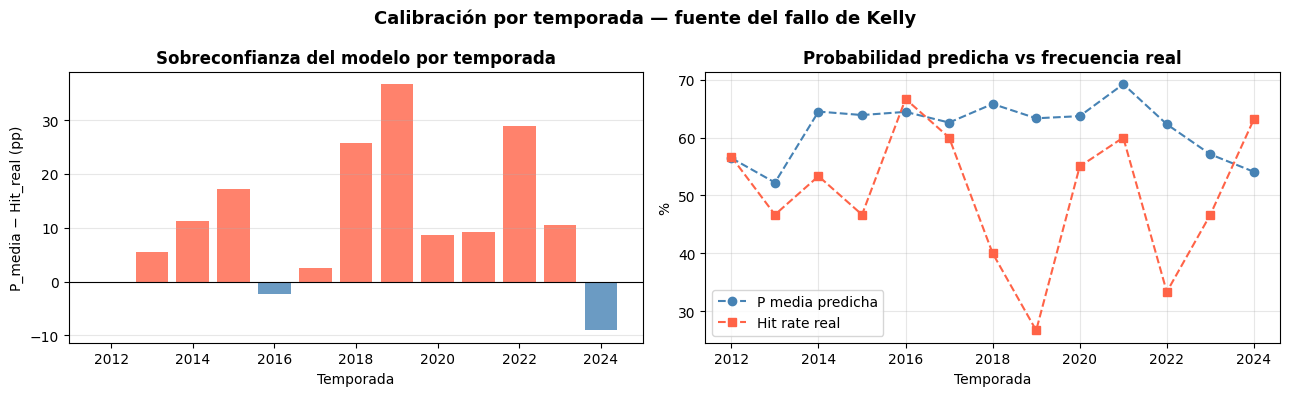

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['tomato' if v > 0 else 'steelblue' for v in over['Overconf']]
axes[0].bar(over['Season'].astype(int), over['Overconf']*100, color=colors, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Temporada')
axes[0].set_ylabel('P_media − Hit_real (pp)')
axes[0].set_title('Sobreconfianza del modelo por temporada', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(over['Season'].astype(int), over['P_media']*100,  'o--',
             color='steelblue', label='P media predicha')
axes[1].plot(over['Season'].astype(int), over['Hit_real']*100, 's--',
             color='tomato',    label='Hit rate real')
axes[1].set_xlabel('Temporada'); axes[1].set_ylabel('%')
axes[1].set_title('Probabilidad predicha vs frecuencia real', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Calibración por temporada — fuente del fallo de Kelly',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/analisis_sobreconfianza.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Análisis profundo de 2018: mala suerte o cambio estructural

2018 es una de las temporadas en negativo: -18.87% ROI, hit 40.0% en 15 apuestas (kill switch activado, sobreconfianza +25.8 pp). Veo si las distribuciones de las apuestas ese año son distintas al resto (cambio estructural) o iguales (mala suerte).

In [10]:
df_18   = df_bets[df_bets['Season'] == 2018].copy()
df_rest = df_bets[df_bets['Season'] != 2018].copy()
df_18['Date'] = pd.to_datetime(df_18['Date'])

print(f'Apuestas 2018 : {len(df_18)}  |  Hit: {df_18["Won"].mean():.1%}')
print(f'P_model media : {df_18["P_Model"].mean():.1%}')
print(f'Sobreconfianza: {(df_18["P_Model"].mean() - df_18["Won"].mean())*100:+.1f} pp')
print(f'ROI           : {df_18["Flat_Profit"].sum()/(len(df_18)*10):+.2%}')
print()

print('--- Por tipo ---')
for bt in df_18['Bet_Type'].unique():
    s = df_18[df_18['Bet_Type'] == bt]
    r = s['Flat_Profit'].sum() / (len(s) * 10)
    print(f'  {bt}: {len(s)} bets | hit={s["Won"].mean():.1%} | '
          f'ROI={r:+.2%} | avg odds={s["Odds"].mean():.2f}')

print()
print('--- Evolución mensual ---')
df_18['Month'] = df_18['Date'].dt.month
for m, g in df_18.groupby('Month'):
    r = g['Flat_Profit'].sum() / (len(g) * 10)
    print(f'  Mes {m:2d}: {len(g):2d} bets | hit={g["Won"].mean():.1%} | ROI={r:+.2%}')


Apuestas 2018 : 15  |  Hit: 40.0%
P_model media : 65.8%
Sobreconfianza: +25.8 pp
ROI           : -18.87%

--- Por tipo ---
  1: 15 bets | hit=40.0% | ROI=-18.87% | avg odds=1.87

--- Evolución mensual ---
  Mes  8:  2 bets | hit=0.0% | ROI=-100.00%
  Mes  9:  5 bets | hit=40.0% | ROI=-26.40%
  Mes 10:  6 bets | hit=50.0% | ROI=+8.17%
  Mes 11:  2 bets | hit=50.0% | ROI=+0.00%


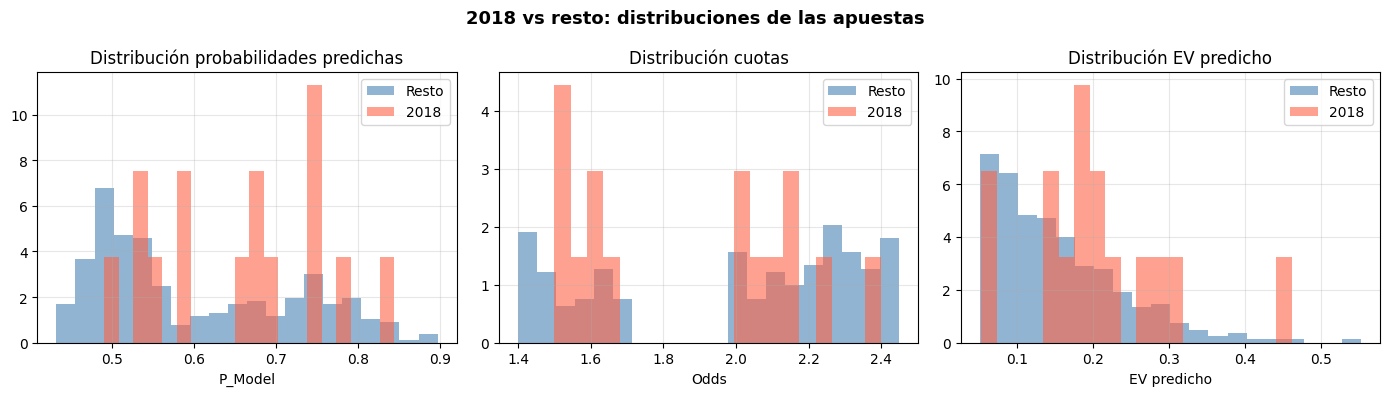

KS P_Model   : stat=0.401  p=0.014  -> DISTINTAS (cambio estructural)
KS EV        : stat=0.399  p=0.014  -> DISTINTAS (cambio estructural)
KS Odds      : stat=0.326  p=0.075  -> iguales (mala suerte)


In [11]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_rest['P_Model'], bins=20, alpha=0.6, color='steelblue',
             label='Resto', density=True)
axes[0].hist(df_18['P_Model'],   bins=20, alpha=0.6, color='tomato',
             label='2018',  density=True)
axes[0].set_xlabel('P_Model')
axes[0].set_title('Distribución probabilidades predichas')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(df_rest['Odds'], bins=20, alpha=0.6, color='steelblue',
             label='Resto', density=True)
axes[1].hist(df_18['Odds'],   bins=20, alpha=0.6, color='tomato',
             label='2018',  density=True)
axes[1].set_xlabel('Odds')
axes[1].set_title('Distribución cuotas')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].hist(df_rest['EV'], bins=20, alpha=0.6, color='steelblue',
             label='Resto', density=True)
axes[2].hist(df_18['EV'],   bins=20, alpha=0.6, color='tomato',
             label='2018',  density=True)
axes[2].set_xlabel('EV predicho')
axes[2].set_title('Distribución EV predicho')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('2018 vs resto: distribuciones de las apuestas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/analisis_2018.png', dpi=120, bbox_inches='tight')
plt.show()

# Test KS: ¿son distribuciones distintas?
for col in ['P_Model', 'EV', 'Odds']:
    stat, pval = stats.ks_2samp(df_18[col], df_rest[col])
    sig = 'DISTINTAS (cambio estructural)' if pval < 0.05 else 'iguales (mala suerte)'
    print(f'KS {col:10s}: stat={stat:.3f}  p={pval:.3f}  -> {sig}')


## 9. Significancia estadística del edge

Con ~26 apuestas/año (kill switch activo, 344 en 13 temporadas), ¿es +2.59% distinguible de cero? Bootstrap por temporada y test binomial.

ROI observado    : +2.59%
IC 95% bootstrap : [-10.77%, +10.77%]
(Bootstrap por temporada — respeta dependencia intra-temporada)
Contiene 0?      : SI -> no significativo al 95%

Hit rate real    : 0.532  (183/344)
Break-even       : 0.505  (odds media = 1.98)
p-valor          : 0.1694
Significativo?   : NO (p>=0.05)

Nota: con ~35 bets/año se necesitan >150 bets para detectar
un edge del 2% con 80% de potencia estadistica.


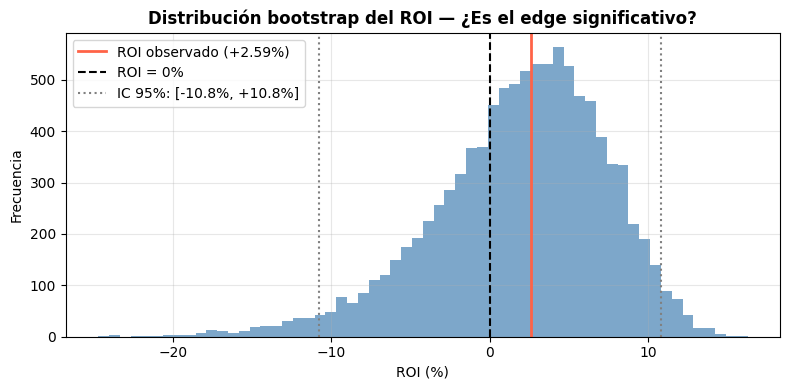

In [12]:
from scipy import stats as scipy_stats

# Bootstrap del ROI global (por temporada, no por apuesta individual)
n_boot = 10_000
rng = np.random.default_rng(42)

seasons_list = df_bets['Season'].unique()

boot_rois = []
for _ in range(n_boot):
    sampled_seasons = rng.choice(seasons_list, size=len(seasons_list), replace=True)
    sampled = pd.concat([df_bets[df_bets['Season'] == s] for s in sampled_seasons])
    boot_rois.append(sampled['Flat_Profit'].sum() / sampled['Flat_Stake'].sum())
boot_rois = np.array(boot_rois)

flat_profits = df_bets['Flat_Profit'].values
flat_stakes  = df_bets['Flat_Stake'].values
ci_low  = np.percentile(boot_rois, 2.5)
ci_high = np.percentile(boot_rois, 97.5)
roi_obs = flat_profits.sum() / flat_stakes.sum()

print(f'ROI observado    : {roi_obs*100:+.2f}%')
print(f'IC 95% bootstrap : [{ci_low*100:+.2f}%, {ci_high*100:+.2f}%]')
print(f'(Bootstrap por temporada — respeta dependencia intra-temporada)')
print(f'Contiene 0?      : '
      f'{"SI -> no significativo al 95%" if ci_low < 0 < ci_high else "NO -> significativo"}')
print()

# Test binomial: hit rate real vs break-even
n_bets   = len(df_bets)
n_wins   = int(df_bets['Won'].sum())
avg_odds = df_bets['Odds'].mean()
be_rate  = 1.0 / avg_odds

binom = scipy_stats.binomtest(n_wins, n_bets, be_rate, alternative='greater')
print(f'Hit rate real    : {n_wins/n_bets:.3f}  ({n_wins}/{n_bets})')
print(f'Break-even       : {be_rate:.3f}  (odds media = {avg_odds:.2f})')
print(f'p-valor          : {binom.pvalue:.4f}')
print(f'Significativo?   : {"SI (p<0.05)" if binom.pvalue < 0.05 else "NO (p>=0.05)"}')
print()
print('Nota: con ~35 bets/año se necesitan >150 bets para detectar')
print('un edge del 2% con 80% de potencia estadistica.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_rois*100, bins=60, color='steelblue', alpha=0.7, edgecolor='none')
ax.axvline(roi_obs*100, color='tomato', linewidth=2, label=f'ROI observado ({roi_obs*100:+.2f}%)')
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', label='ROI = 0%')
ax.axvline(ci_low*100,  color='gray', linestyle=':', linewidth=1.5,
           label=f'IC 95%: [{ci_low*100:+.1f}%, {ci_high*100:+.1f}%]')
ax.axvline(ci_high*100, color='gray', linestyle=':', linewidth=1.5)
ax.set_xlabel('ROI (%)'); ax.set_ylabel('Frecuencia')
ax.set_title('Distribución bootstrap del ROI — ¿Es el edge significativo?',
             fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/analisis_bootstrap_roi.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Calibración: sigmoid vs isotonic

La ECE sobre las apuestas seleccionadas indica sobreconfianza moderada. Isotónica con `TimeSeriesSplit(n_splits=3)` tiene poca muestra para corregir las probabilidades extremas. Platt (sigmoid) es paramétrica con dos parámetros, más estable con muestras pequeñas.

Comparo las dos en walk-forward 2012-2024 (13 temporadas) midiendo ECE por temporada y global, ROI flat y Kelly, hit rate real vs predicho. Mismo setup que el backtest principal: FIRST_TEST=2012, sliding 5, kill switch activo.

In [13]:
import sys, warnings, time
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit

DATA_PATH = '../data/df_final_clean.csv'
FEATURES  = [
    'Home_Elo_Calc','Away_Elo_Calc','Elo_Diff',
    'Home_Market_Value','Away_Market_Value','Log_Value_Diff',
    'Diff_FIFA_Ova','Diff_FIFA_Mid','Diff_FIFA_Def','Diff_FIFA_Att',
    'Home_Streak_L5','Away_Streak_L5','Home_H2H_L3','Away_H2H_L3',
]
# Visitante excluido: sin edge real (ROI -17.55% historico)
ODDS_FILTER = [('1',1.40,1.70),('1',2.00,2.50)]
import json
with open('../results/best_params.json') as _f:
    _bp = json.load(_f)
XGB_PARAMS = {**_bp, 'objective':'multi:softprob', 'num_class':3, 'eval_metric':'mlogloss',
              'random_state':42, 'verbosity':0, 'n_jobs':-1}
CALIB_CV     = TimeSeriesSplit(n_splits=3)
TRAIN_WINDOW = 5
FIRST_TEST   = 2012
INIT_BK      = 1000.0
FLAT_STAKE   = 10.0
KELLY_FRAC   = 0.25
KELLY_MAX    = 0.05
MIN_EV       = 0.05
KILL_MIN     = 15
# KILL_THR rebajado a 0.08: con sobreconfianza sistematica de 8-12 pp el 0.12 nunca se activaba
KILL_THR     = 0.08

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['FTR'].isin(['H','D','A'])].dropna(subset=['Season']).copy()
df['Season'] = df['Season'].astype(int)
df = df.sort_values('Date').reset_index(drop=True)
for c in FEATURES:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
df = df.dropna(subset=FEATURES+['Target','B365H','B365D','B365A'])

all_seasons  = sorted(df['Season'].unique())
test_seasons = [s for s in all_seasons if s >= FIRST_TEST]

def ece(p_pred, y_true, n_bins=10):
    bins, val = np.linspace(0, 1, n_bins+1), 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (p_pred >= lo) & (p_pred < hi)
        if m.sum() == 0: continue
        val += m.mean() * abs(p_pred[m].mean() - y_true[m].mean())
    return val

def kelly_stake(p, odds):
    return max(0.0, min((p*odds-1)/(odds-1)*KELLY_FRAC, KELLY_MAX)) * INIT_BK

def run_wf(method):
    all_bets = []
    t0 = time.time()
    for fold, test_s in enumerate(test_seasons):
        prior = [s for s in all_seasons if s < test_s]
        tr_s  = prior[-TRAIN_WINDOW:]
        tr, te = df['Season'].isin(tr_s), df['Season'] == test_s
        X_tr = df.loc[tr, FEATURES].values
        y_tr = df.loc[tr, 'Target'].values
        df_te = df[te].reset_index(drop=True)
        if len(X_tr) < 50 or len(df_te) == 0: continue

        model = CalibratedClassifierCV(
            XGBClassifier(**XGB_PARAMS), method=method, cv=CALIB_CV
        )
        model.fit(X_tr, y_tr)
        classes = list(model.classes_)
        p_all   = model.predict_proba(df_te[FEATURES].values)
        p_H = p_all[:, classes.index(2)]
        p_D = p_all[:, classes.index(1)]
        p_A = p_all[:, classes.index(0)]

        bets_season = []
        killed = False
        for i, row in df_te.iterrows():
            if killed:
                break
            oh, od, oa = float(row['B365H']), float(row['B365D']), float(row['B365A'])
            if oh < 1.05 or od < 1.05 or oa < 1.05: continue
            ftr = str(row['FTR'])
            for bt, p, odds, won in [('1',p_H[i],oh,ftr=='H'),
                                      ('X',p_D[i],od,ftr=='D'),
                                      ('2',p_A[i],oa,ftr=='A')]:
                ev = p * odds - 1
                if ev <= MIN_EV: continue
                if not any(bt==b and lo<=odds<hi for b,lo,hi in ODDS_FILTER): continue
                ks = kelly_stake(p, odds)
                bets_season.append({
                    'Season': test_s, 'P_Model': p, 'Won': int(won),
                    'Flat_P': FLAT_STAKE*(odds-1) if won else -FLAT_STAKE,
                    'Kelly_P': ks*(odds-1) if won else -ks,
                    'Kelly_S': ks, 'Flat_S': FLAT_STAKE,
                })
            # Kill switch correcto: obs vs P_Model predicho
            if len(bets_season) >= KILL_MIN:
                obs = sum(b['Won'] for b in bets_season) / len(bets_season)
                exp = sum(b['P_Model'] for b in bets_season) / len(bets_season)
                if obs < exp - KILL_THR:
                    killed = True

        all_bets.extend(bets_season)
        print(f'  [{method}] fold {test_s} ({fold+1}/{len(test_seasons)}) '
              f'— {time.time()-t0:.0f}s', end='\r')
    print()
    return all_bets

def summarise(bets_list):
    ab  = pd.DataFrame(bets_list)
    res = ab.groupby('Season').apply(lambda g: pd.Series({
        'N_Bets':    len(g),
        'Hit_real':  round(g['Won'].mean(), 4),
        'P_media':   round(g['P_Model'].mean(), 4),
        'Overconf':  round(g['P_Model'].mean() - g['Won'].mean(), 4),
        'ECE':       round(ece(g['P_Model'].values, g['Won'].values.astype(float)), 4),
        'Flat_ROI':  round(g['Flat_P'].sum() / g['Flat_S'].sum(), 4),
        'Kelly_ROI': round(g['Kelly_P'].sum()/g['Kelly_S'].sum()
                           if g['Kelly_S'].sum()>0 else 0, 4),
        'Flat_PnL':  round(g['Flat_P'].sum(), 2),
        'Kelly_PnL': round(g['Kelly_P'].sum(), 2),
    }), include_groups=False).reset_index()
    global_ece = ece(ab['P_Model'].values, ab['Won'].values.astype(float))
    fr  = ab['Flat_P'].sum() / ab['Flat_S'].sum()
    kr  = ab['Kelly_P'].sum() / ab['Kelly_S'].sum() if ab['Kelly_S'].sum()>0 else 0
    pos = (res['Flat_ROI'] > 0).sum()
    return res, global_ece, fr, kr, int(pos), len(res)

print('Walk-forward isotonic...')
res_iso, ece_iso, fr_iso, kr_iso, pos_iso, n_iso = summarise(run_wf('isotonic'))
print('Walk-forward sigmoid...')
res_sig, ece_sig, fr_sig, kr_sig, pos_sig, n_sig = summarise(run_wf('sigmoid'))
print('Listo.')

Walk-forward isotonic...
  [isotonic] fold 2024 (13/13) — 12s
Walk-forward sigmoid...
  [sigmoid] fold 2024 (13/13) — 16s
Listo.


In [14]:
# --- Tabla comparativa global ---
print('=' * 62)
print(f'{"Metrica":<28} {"Isotonic":>15} {"Sigmoid":>15}')
print('-' * 62)
print(f'{"ECE global":<28} {ece_iso:>15.4f} {ece_sig:>15.4f}')
print(f'{"Flat ROI":<28} {fr_iso*100:>14.2f}% {fr_sig*100:>14.2f}%')
print(f'{"Kelly ROI":<28} {kr_iso*100:>14.2f}% {kr_sig*100:>14.2f}%')
print(f'{"Temporadas positivas":<28} {pos_iso:>10}/{n_iso}     {pos_sig:>10}/{n_sig}')
print('=' * 62)
print()

# --- Tabla por temporada ---
comp = res_iso[['Season','N_Bets','Overconf','ECE','Flat_ROI']].copy()
comp.columns = ['Season','N_Bets','Overconf_iso','ECE_iso','FlatROI_iso']
comp = comp.merge(
    res_sig[['Season','Overconf','ECE','Flat_ROI']].rename(
        columns={'Overconf':'Overconf_sig','ECE':'ECE_sig','Flat_ROI':'FlatROI_sig'}),
    on='Season'
)
comp['ECE_mejora']  = comp['ECE_iso'] - comp['ECE_sig']
comp['ROI_mejora']  = (comp['FlatROI_sig'] - comp['FlatROI_iso']) * 100
print(comp[['Season','N_Bets','ECE_iso','ECE_sig','ECE_mejora',
            'FlatROI_iso','FlatROI_sig','ROI_mejora']].to_string(index=False))


Metrica                             Isotonic         Sigmoid
--------------------------------------------------------------
ECE global                            0.0707          0.0961
Flat ROI                               2.59%          -4.33%
Kelly ROI                             -0.49%          -2.67%
Temporadas positivas                  5/13              3/13

 Season  N_Bets  ECE_iso  ECE_sig  ECE_mejora  FlatROI_iso  FlatROI_sig  ROI_mejora
   2012    60.0   0.0531   0.0690     -0.0159       0.1618       0.0323      -12.95
   2013    45.0   0.0801   0.0782      0.0019       0.0247      -0.0249       -4.96
   2014    15.0   0.2041   0.3236     -0.1195      -0.0327      -0.5467      -51.40
   2015    15.0   0.1723   0.2213     -0.0490      -0.1613      -0.3000      -13.87
   2016    30.0   0.1573   0.2356     -0.0783       0.2063      -0.2007      -40.70
   2017    65.0   0.1336   0.0948      0.0388       0.1428       0.1374       -0.54
   2018    15.0   0.4182   0.4822     -0.06

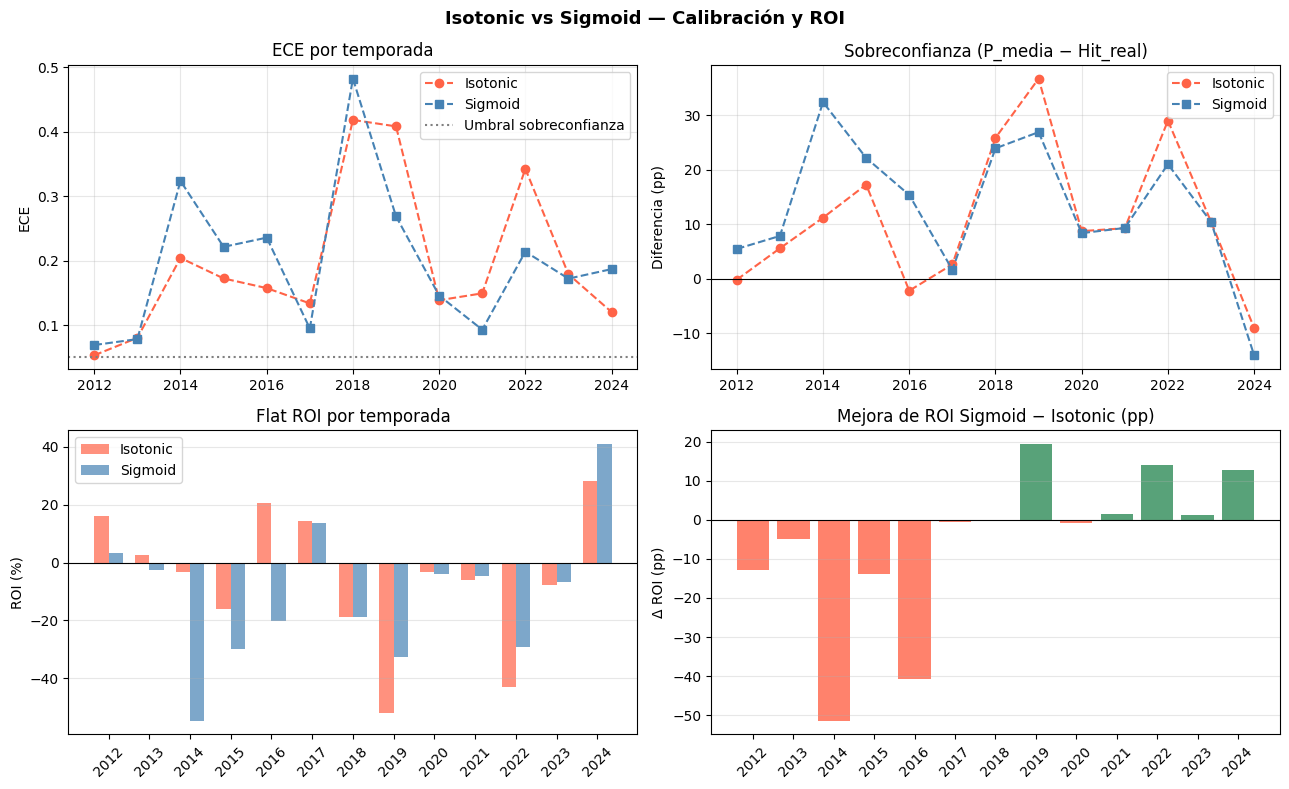

Bankroll final Isotonic: 1,089 EUR  (ROI +2.59%)
Bankroll final Sigmoid : 841 EUR  (ROI -4.33%)
ECE Isotonic: 0.0707  |  ECE Sigmoid: 0.0961
Método preferido (menor ECE): Isotonic


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

seasons = comp['Season'].astype(int)

# ECE por temporada
axes[0,0].plot(seasons, comp['ECE_iso'], 'o--', color='tomato',    label='Isotonic')
axes[0,0].plot(seasons, comp['ECE_sig'], 's--', color='steelblue', label='Sigmoid')
axes[0,0].axhline(0.05, color='gray', linestyle=':', label='Umbral sobreconfianza')
axes[0,0].set_title('ECE por temporada'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
axes[0,0].set_ylabel('ECE')

# Sobreconfianza por temporada
axes[0,1].plot(seasons, comp['Overconf_iso']*100, 'o--', color='tomato',    label='Isotonic')
axes[0,1].plot(seasons, comp['Overconf_sig']*100, 's--', color='steelblue', label='Sigmoid')
axes[0,1].axhline(0, color='black', linewidth=0.8)
axes[0,1].set_title('Sobreconfianza (P_media − Hit_real)'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
axes[0,1].set_ylabel('Diferencia (pp)')

# ROI flat por temporada
x = range(len(seasons))
w = 0.35
axes[1,0].bar([i-w/2 for i in x], comp['FlatROI_iso']*100, w,
              color='tomato', alpha=0.7, label='Isotonic')
axes[1,0].bar([i+w/2 for i in x], comp['FlatROI_sig']*100, w,
              color='steelblue', alpha=0.7, label='Sigmoid')
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(seasons.tolist(), rotation=45)
axes[1,0].set_title('Flat ROI por temporada'); axes[1,0].legend(); axes[1,0].grid(axis='y',alpha=0.3)
axes[1,0].set_ylabel('ROI (%)')

# Mejora de ROI por usar sigmoid
colors = ['seagreen' if v > 0 else 'tomato' for v in comp['ROI_mejora']]
axes[1,1].bar(x, comp['ROI_mejora'], color=colors, alpha=0.8)
axes[1,1].axhline(0, color='black', linewidth=0.8)
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(seasons.tolist(), rotation=45)
axes[1,1].set_title('Mejora de ROI Sigmoid − Isotonic (pp)'); axes[1,1].grid(axis='y',alpha=0.3)
axes[1,1].set_ylabel('Δ ROI (pp)')

plt.suptitle('Isotonic vs Sigmoid — Calibración y ROI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/calibracion_isotonic_vs_sigmoid.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Bankroll final Isotonic: {INIT_BK + res_iso["Flat_PnL"].sum():,.0f} EUR  '
      f'(ROI {fr_iso*100:+.2f}%)')
print(f'Bankroll final Sigmoid : {INIT_BK + res_sig["Flat_PnL"].sum():,.0f} EUR  '
      f'(ROI {fr_sig*100:+.2f}%)')
print(f'ECE Isotonic: {ece_iso:.4f}  |  ECE Sigmoid: {ece_sig:.4f}')
print(f'Método preferido (menor ECE): {"Sigmoid" if ece_sig < ece_iso else "Isotonic"}')


## 11. Conclusiones y problemas detectados

### Backtest principal (walk-forward 2012-2024, sliding 5, kill switch, isotonic con TimeSeriesSplit)

- 344 apuestas, hit rate 53.2%, break-even 50.5% (cuota media 1.98, EV medio 15.5%).
- Flat ROI +2.59%, Kelly ROI -1.82%, BK final flat 1089 EUR.
- 5/13 temporadas positivas en flat, 5/13 en Kelly.
- ECE global 0.0707, sobreconfianza moderada.
- IC 95% bootstrap del Flat ROI: [-10.77%, +10.77%]. Contiene cero, así que el edge no es estadísticamente distinguible del azar al 95%.
- p-valor binomial sobre el hit rate: 0.169. Tampoco significativo.

### Calibración por temporada

- Bien calibradas (ECE < 0.10): 2012 (0.053, 60 bets), 2013 (0.080, 45), 2017 (0.134, 65 bets — ECE algo alta pero con muestra grande).
- Calibración pobre (ECE > 0.20): 2014 (0.204), 2015 (0.172), 2018 (0.418), 2019 (0.408), 2022 (0.342). Las cuatro últimas tienen n=15 (kill switch corta pronto) y la muestra queda muy ruidosa.
- Caso extremo 2019: hit 26.7%, P_media 0.63, sobreconfianza +29.4 pp, ROI -52.00%. Una temporada catastrófica que arrastra todo el agregado.

### Por tipo de apuesta

- Local (1): 344 bets, hit 53.2%, EV medio +15.5%, cuota media 1.98, ROI +2.59%.
- Visitante (2): excluido del filtro. En pruebas previas dio 20 apuestas con ROI -17.55%, sin señal real.
- Empate (X): excluido. Hit rate ~25% prácticamente igual a la implícita (~26%), no hay edge diferencial.

### Sigmoid vs isotonic

- Isotonic: ECE 0.0707, Flat ROI +2.59%, Kelly -0.49%, 5/13, BK 1089.
- Sigmoid: ECE 0.0961, Flat ROI -4.33%, Kelly -2.67%, 3/13, BK 841.

Isotonic gana claro: mejor ECE, mejor ROI (~7 pp más) y casi el doble de temporadas positivas. Justifica empíricamente la elección de isotonic en el backtest principal.

### Lectura honesta

El edge en este periodo es positivo en agregado pero estadísticamente débil. +2.59% suena mejor que cero, pero el IC bootstrap incluye claramente el cero (de hecho es prácticamente simétrico alrededor del cero, [-10.77%, +10.77%]), así que no se puede afirmar que el edge sea real con esta muestra. La distribución por temporada es 8 negativas (2014, 2015, 2018, 2019, 2020, 2021, 2022, 2023) frente a 5 positivas (2012, 2013, 2016, 2017, 2024). Las temporadas buenas (especialmente 2024 con +28.21% y 2016 con +20.63%) tiran del agregado por encima de las catastróficas (2019 -52%, 2022 -43%).

Con ~26 apuestas/año los IC por temporada son demasiado anchos para concluir nada por temporada individual. Para detectar un edge del 2% con 80% de potencia harían falta más de 150 bets/año, mucho más de lo que produce la configuración actual con kill switch.

### Próximos pasos

- Probar reglas de decisión más selectivas: notebook 07 (filtros de probabilidad y ratio modelo/mercado), notebook 06 (empate).
- Subir KILL_MIN o calibrar KILL_THR para no truncar temporadas con tan poca muestra y reducir el riesgo de catástrofes tipo 2019.
- Revisar el sesgo de los hiperparámetros del futuro (sección 3.4.3): Optuna optimiza sobre 2018-2023 y los aplico a 2012-2017.